In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

import numpy as np
import sys, pickle, os, torch, cv2
# replace this path with path to GMIC
#sys.path.append("/path/to/GMIC")

from src.data_loading import loading
from src.modeling import gmic as gmic

from PIL import Image

### You need to obtain the cropped images (bash run.sh) before using this demo.

Step 1: prepare the input data

In [3]:
with open("sample_output/data.pkl", "rb") as f:
    exam_list = pickle.load(f)

print(exam_list[3])
datum = exam_list[3]
view = "L-CC"
short_file_path = datum[view][0]
print(short_file_path)

{'horizontal_flip': 'NO', 'L-CC': ['3_L-CC'], 'L-MLO': ['3_L-MLO'], 'R-MLO': ['3_R-MLO'], 'R-CC': ['3_R-CC'], 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 1, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 1}, 'L-CC_benign_seg': ['3_L-CC_benign'], 'L-CC_malignant_seg': ['3_L-CC_malignant'], 'L-MLO_benign_seg': ['3_L-MLO_benign'], 'L-MLO_malignant_seg': ['3_L-MLO_malignant'], 'R-MLO_benign_seg': ['3_R-MLO_benign'], 'R-MLO_malignant_seg': ['3_R-MLO_malignant'], 'R-CC_benign_seg': ['3_R-CC_benign'], 'R-CC_malignant_seg': ['3_R-CC_malignant'], 'window_location': {'L-CC': [(0, 3525, 0, 2280)], 'R-CC': [(0, 3693, 0, 2591)], 'L-MLO': [(0, 3931, 0, 2483)], 'R-MLO': [(0, 3965, 0, 2707)]}, 'rightmost_points': {'L-CC': [((1945, 2039), 2229)], 'R-CC': [((2263, 2308), 2541)], 'L-MLO': [((2514, 2583), 2432)], 'R-MLO': [((2483, 2567), 2657)]}, 'bottommost_points': {'L-CC': [(3474, (789, 877))], 'R-CC': [(3642, (1221, 1241))], 'L-MLO': [(3880, (1060, 1097))], '

Step 2: load the image

<class 'numpy.ndarray'>
0.0
4092.0
(3525, 2280)


/opt/homebrew/Caskroom/miniforge/base/envs/learning/lib/python3.11/site-packages/imageio/plugins/pillow.py:304: UserWarning: Loading 16-bit (uint16) PNG as int32 due to limitations in pillow's PNG decoder. This will be fixed in a future version of pillow which will make this warning dissapear.
  warnings.warn(


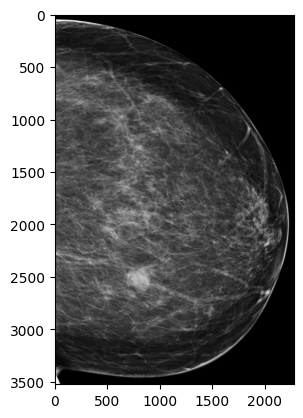

In [ ]:
loaded_image = loading.load_image(
                    image_path=os.path.join("sample_output/cropped_images/", short_file_path + ".png"),
                    view=view, horizontal_flip=datum["horizontal_flip"])

print(type(loaded_image))
print(np.min(loaded_image))
print(np.max(loaded_image))
print(loaded_image.shape)

plt.imshow(loaded_image, cmap="gray")

Step 3: preprocess the image

In [ ]:
loaded_image = loading.process_image(loaded_image, view, datum["best_center"][view][0])

Let's visualize a sample image

(2944, 1920)
4.530258


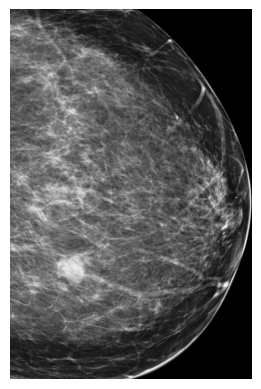

In [ ]:
print(loaded_image.shape)
print(np.max(loaded_image))
plt.imshow(loaded_image, cmap="Greys_r")
plt.axis("off")
plt.savefig("mammoOriginal.png")
plt.show()

Step 4: load the model

In [ ]:
parameters = {
        "device_type":"cpu",
        "cam_size": (46, 30),
        "K": 6,
        "crop_shape": (256, 256),
        "percent_t": 0.02, 
        "post_processing_dim": 256,
        "num_classes": 2
    }

In [ ]:
model = gmic.GMIC(parameters)

In [ ]:
model.load_state_dict(torch.load("models/sample_model_1.p", map_location="cpu"), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['shared_rep_filter.weight'])

Step 5: inference

In [ ]:
tensor_batch = torch.Tensor(np.expand_dims(np.expand_dims(loaded_image, 0), 0).copy())
output = model(tensor_batch)
pred_numpy = output.data.cpu().numpy()
begnin_pred = pred_numpy[0,0]
malignant_pred = pred_numpy[0, 1]

In [ ]:
print("begnin prediction = {}".format(begnin_pred))
print("malignant prediction = {}".format(malignant_pred))

begnin prediction = 0.4033045768737793
malignant prediction = 0.2067270427942276


Step 6: visualize the saliency map

/var/folders/d7/q72cpd5d6bv6knpx85s28lq80000gn/T/ipykernel_4881/3587859275.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  alpha_red = plt.cm.get_cmap('Reds')


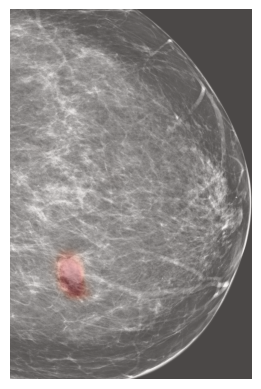

In [ ]:
saliency_maps = model.saliency_map.data.cpu().numpy()
malignant_saliency_map = saliency_maps[0,1,:,:]
alphas = np.abs(np.linspace(0, 0.95, 259))
alpha_red = plt.cm.get_cmap('Reds')
plt.figure()
plt.imshow(loaded_image, cmap="Greys_r")
plt.imshow(cv2.resize(malignant_saliency_map, (1920, 2944)), alpha=0.3, cmap=alpha_red, clim=[0.0, 1.0])
plt.axis("off")
plt.savefig("mammoResult.png")
plt.show()